In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 기존의 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)
-
https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명
- https://www.mql5.com/ko/articles/11200

In [2]:
# 섭씨온도를 화씨온도로 출력
def celsius_to_faherenheit(c):
    return c * 1.8 + 32

In [3]:
input_c = int(input('섭씨온도는?'))
print('화씨온도는', celsius_to_faherenheit(input_c))

섭씨온도는?1
화씨온도는 33.8


# 2. 머신러닝 프로그램 방식
```
1. 데이터 확보 및 생성
2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋), 검증데이터셋, 시험데이터셋으로 분할
3. 모델구성
4. 모델 학습과정 설정
5. 모델 학습시키기
6. 모델 평가(시험데이터셋으로)
    <모델 저장>
7. 모델 저장 및 사용(입력값이 주어지면 예측값 받기)
```
## 2.1 노이즈가 없는 데이터로 실습

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 1. 데이터 생성
data_C = np.arange(100) # 0부터 99까지
data_C # 독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [9]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('학습시 독립변수 :', scaled_data_C)
print('학습시 타겟변수 :', scaled_data_F)

학습시 독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
학습시 타겟변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1

In [11]:
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [13]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정

model = Sequential()
# model.add(Input(shape=(1,) ))
# model.add(Dense(1))
model.add(Dense(units=1,           # 타겟(종속)변수의 갯수
                input_shape=(1,))) # 입력(독립)변수의 shape

In [15]:
# 4. 모델 학습과정 설정
model.compile(loss="mse", # 손실함수 - 모델 학습 중 오차를 최소화하기 위해 사용
              optimizer="rmsprop", # 옵티마이저
              metrics=['mae']) # 평가지표
# mse : 오차 제곱의 평균(이상치 반영)
# mae : 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [17]:
# 학습전 예측 
model.predict(np.array([[0],
                       [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 94ms/step


array([[ 0.        ],
       [-0.01668285]], dtype=float32)

In [18]:
# 학습전 모델 저장
model.save('model/before_learning.h5')

In [19]:
# 5. 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력변수(훈련데이터)
                 scaled_data_F, # 타겟변수(훈련데이터)
                 epochs=1000, # 학습횟수
                 verbose=2) # 학습시 출력여부(0:학습내용출력X)

Epoch 1/1000
4/4 - 0s - loss: 5.1319 - mae: 2.0324 - 338ms/epoch - 84ms/step
Epoch 2/1000
4/4 - 0s - loss: 5.0805 - mae: 2.0209 - 8ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 5.0475 - mae: 2.0135 - 8ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 5.0169 - mae: 2.0065 - 7ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 4.9891 - mae: 2.0000 - 8ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 4.9611 - mae: 1.9937 - 8ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 4.9335 - mae: 1.9874 - 8ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 4.9045 - mae: 1.9807 - 9ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 4.8833 - mae: 1.9758 - 7ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 4.8597 - mae: 1.9704 - 8ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 4.8344 - mae: 1.9645 - 9ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 4.8065 - mae: 1.9579 - 7ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 4.7818 - mae: 1.9524 - 8ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - loss: 

4/4 - 0s - loss: 2.6980 - mae: 1.3940 - 7ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 2.6816 - mae: 1.3889 - 7ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 2.6642 - mae: 1.3839 - 8ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 2.6455 - mae: 1.3781 - 6ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 2.6280 - mae: 1.3729 - 6ms/epoch - 1ms/step
Epoch 115/1000
4/4 - 0s - loss: 2.6079 - mae: 1.3668 - 5ms/epoch - 1ms/step
Epoch 116/1000
4/4 - 0s - loss: 2.5909 - mae: 1.3615 - 7ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 2.5758 - mae: 1.3569 - 5ms/epoch - 1ms/step
Epoch 118/1000
4/4 - 0s - loss: 2.5570 - mae: 1.3511 - 6ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 2.5383 - mae: 1.3453 - 5ms/epoch - 1ms/step
Epoch 120/1000
4/4 - 0s - loss: 2.5207 - mae: 1.3400 - 6ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 2.5027 - mae: 1.3346 - 5ms/epoch - 1ms/step
Epoch 122/1000
4/4 - 0s - loss: 2.4849 - mae: 1.3289 - 6ms/epoch - 1ms/step
Epoch 123/1000
4/4 - 0s - l

Epoch 218/1000
4/4 - 0s - loss: 1.1642 - mae: 0.8811 - 6ms/epoch - 1ms/step
Epoch 219/1000
4/4 - 0s - loss: 1.1552 - mae: 0.8776 - 6ms/epoch - 1ms/step
Epoch 220/1000
4/4 - 0s - loss: 1.1451 - mae: 0.8738 - 7ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 1.1352 - mae: 0.8699 - 7ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 1.1259 - mae: 0.8663 - 6ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 1.1137 - mae: 0.8617 - 7ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 1.1038 - mae: 0.8578 - 5ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 1.0940 - mae: 0.8542 - 8ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 1.0844 - mae: 0.8505 - 6ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 1.0758 - mae: 0.8471 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 1.0679 - mae: 0.8441 - 9ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 1.0581 - mae: 0.8401 - 6ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 1.0481 - mae: 0.8362 - 9ms/epoch - 2ms/step
Epoch 231/10

Epoch 326/1000
4/4 - 0s - loss: 0.4519 - mae: 0.5740 - 7ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.4484 - mae: 0.5722 - 8ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.4451 - mae: 0.5703 - 8ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.4425 - mae: 0.5690 - 6ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.4387 - mae: 0.5670 - 7ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.4354 - mae: 0.5652 - 8ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.4319 - mae: 0.5631 - 6ms/epoch - 2ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.4286 - mae: 0.5614 - 7ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.4254 - mae: 0.5596 - 6ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.4233 - mae: 0.5585 - 8ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.4202 - mae: 0.5567 - 8ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.4187 - mae: 0.5559 - 7ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.4173 - mae: 0.5550 - 7ms/epoch - 2ms/step
Epoch 339/10

Epoch 434/1000
4/4 - 0s - loss: 0.2891 - mae: 0.4649 - 6ms/epoch - 1ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.2882 - mae: 0.4641 - 7ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.2873 - mae: 0.4634 - 5ms/epoch - 1ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.2861 - mae: 0.4623 - 7ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.2852 - mae: 0.4615 - 5ms/epoch - 1ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.2845 - mae: 0.4608 - 7ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.2837 - mae: 0.4603 - 6ms/epoch - 1ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.2828 - mae: 0.4596 - 6ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.2817 - mae: 0.4586 - 6ms/epoch - 1ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.2806 - mae: 0.4577 - 7ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.2797 - mae: 0.4570 - 6ms/epoch - 1ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.2786 - mae: 0.4562 - 6ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.2775 - mae: 0.4551 - 7ms/epoch - 2ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.1880 - mae: 0.3743 - 5ms/epoch - 1ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1870 - mae: 0.3734 - 7ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.1862 - mae: 0.3726 - 6ms/epoch - 1ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.1855 - mae: 0.3719 - 6ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.1847 - mae: 0.3711 - 5ms/epoch - 1ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.1838 - mae: 0.3702 - 7ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.1829 - mae: 0.3692 - 5ms/epoch - 1ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.1821 - mae: 0.3683 - 7ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.1813 - mae: 0.3675 - 5ms/epoch - 1ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.1806 - mae: 0.3667 - 7ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.1798 - mae: 0.3659 - 6ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.1791 - mae: 0.3652 - 7ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.1783 - mae: 0.3646 - 10ms/epoch - 3ms/step
Epoch 555/1

Epoch 650/1000
4/4 - 0s - loss: 0.1098 - mae: 0.2861 - 6ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.1093 - mae: 0.2855 - 7ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.1087 - mae: 0.2846 - 6ms/epoch - 1ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.1082 - mae: 0.2840 - 8ms/epoch - 2ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.1076 - mae: 0.2833 - 5ms/epoch - 1ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.1070 - mae: 0.2824 - 7ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.1065 - mae: 0.2817 - 5ms/epoch - 1ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.1058 - mae: 0.2809 - 7ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.1051 - mae: 0.2799 - 5ms/epoch - 1ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.1046 - mae: 0.2792 - 7ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.1040 - mae: 0.2784 - 5ms/epoch - 1ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.1033 - mae: 0.2775 - 7ms/epoch - 2ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.1029 - mae: 0.2767 - 6ms/epoch - 1ms/step
Epoch 663/10

Epoch 758/1000
4/4 - 0s - loss: 0.0520 - mae: 0.1967 - 6ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0515 - mae: 0.1959 - 5ms/epoch - 1ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0510 - mae: 0.1948 - 16ms/epoch - 4ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0505 - mae: 0.1940 - 6ms/epoch - 1ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0500 - mae: 0.1931 - 7ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0496 - mae: 0.1923 - 6ms/epoch - 2ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0492 - mae: 0.1916 - 7ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0489 - mae: 0.1909 - 5ms/epoch - 1ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0484 - mae: 0.1900 - 6ms/epoch - 1ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0480 - mae: 0.1893 - 5ms/epoch - 1ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0477 - mae: 0.1885 - 6ms/epoch - 1ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0473 - mae: 0.1877 - 6ms/epoch - 1ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0469 - mae: 0.1870 - 7ms/epoch - 2ms/step
Epoch 771/1

Epoch 866/1000
4/4 - 0s - loss: 0.0152 - mae: 0.1066 - 9ms/epoch - 2ms/step
Epoch 867/1000
4/4 - 0s - loss: 0.0149 - mae: 0.1056 - 7ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 0.0147 - mae: 0.1048 - 8ms/epoch - 2ms/step
Epoch 869/1000
4/4 - 0s - loss: 0.0145 - mae: 0.1038 - 7ms/epoch - 2ms/step
Epoch 870/1000
4/4 - 0s - loss: 0.0142 - mae: 0.1030 - 7ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 0.0140 - mae: 0.1023 - 8ms/epoch - 2ms/step
Epoch 872/1000
4/4 - 0s - loss: 0.0138 - mae: 0.1013 - 7ms/epoch - 2ms/step
Epoch 873/1000
4/4 - 0s - loss: 0.0135 - mae: 0.1003 - 8ms/epoch - 2ms/step
Epoch 874/1000
4/4 - 0s - loss: 0.0133 - mae: 0.0995 - 6ms/epoch - 1ms/step
Epoch 875/1000
4/4 - 0s - loss: 0.0131 - mae: 0.0988 - 6ms/epoch - 1ms/step
Epoch 876/1000
4/4 - 0s - loss: 0.0129 - mae: 0.0980 - 5ms/epoch - 1ms/step
Epoch 877/1000
4/4 - 0s - loss: 0.0127 - mae: 0.0973 - 6ms/epoch - 1ms/step
Epoch 878/1000
4/4 - 0s - loss: 0.0125 - mae: 0.0965 - 5ms/epoch - 1ms/step
Epoch 879/10

Epoch 974/1000
4/4 - 0s - loss: 4.6357e-04 - mae: 0.0186 - 7ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 4.2443e-04 - mae: 0.0178 - 6ms/epoch - 2ms/step
Epoch 976/1000
4/4 - 0s - loss: 3.8423e-04 - mae: 0.0170 - 7ms/epoch - 2ms/step
Epoch 977/1000
4/4 - 0s - loss: 3.5554e-04 - mae: 0.0162 - 7ms/epoch - 2ms/step
Epoch 978/1000
4/4 - 0s - loss: 3.2416e-04 - mae: 0.0155 - 7ms/epoch - 2ms/step
Epoch 979/1000
4/4 - 0s - loss: 2.9704e-04 - mae: 0.0149 - 7ms/epoch - 2ms/step
Epoch 980/1000
4/4 - 0s - loss: 2.6939e-04 - mae: 0.0142 - 6ms/epoch - 2ms/step
Epoch 981/1000
4/4 - 0s - loss: 2.3746e-04 - mae: 0.0133 - 7ms/epoch - 2ms/step
Epoch 982/1000
4/4 - 0s - loss: 2.0633e-04 - mae: 0.0124 - 7ms/epoch - 2ms/step
Epoch 983/1000
4/4 - 0s - loss: 1.8140e-04 - mae: 0.0116 - 6ms/epoch - 1ms/step
Epoch 984/1000
4/4 - 0s - loss: 1.6354e-04 - mae: 0.0109 - 6ms/epoch - 1ms/step
Epoch 985/1000
4/4 - 0s - loss: 1.4286e-04 - mae: 0.0103 - 8ms/epoch - 2ms/step
Epoch 986/1000
4/4 - 0s - loss: 1.2333e-

In [23]:
# 6. 모델 평가(그래프를 통해 loss와 metrics값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history['loss'][:5])
print(hist.history['mae'][:5])

dict_keys(['loss', 'mae'])
[5.131878852844238, 5.080498218536377, 5.047472953796387, 5.016932964324951, 4.989089488983154]
[2.0324318408966064, 2.0209405422210693, 2.0135157108306885, 2.0064589977264404, 2.000035285949707]


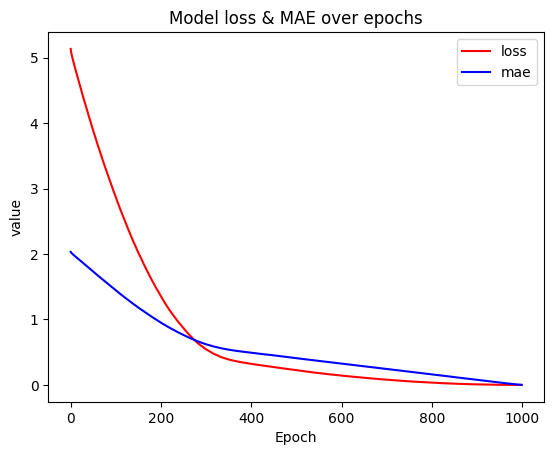

In [27]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend() # 범례 label 추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Model loss & MAE over epochs')
plt.show()

In [28]:
# 7. 모델 저장 및 사용
# 학습 후 예측(예측하고자하는 값은 2차원으로)
model.predict(np.array([[0],
                       [0.01]]))

1/1 [==============================] - 0s 21ms/step


array([[0.32169214],
       [0.33963946]], dtype=float32)

In [29]:
model.save('model/after_learning.h5')

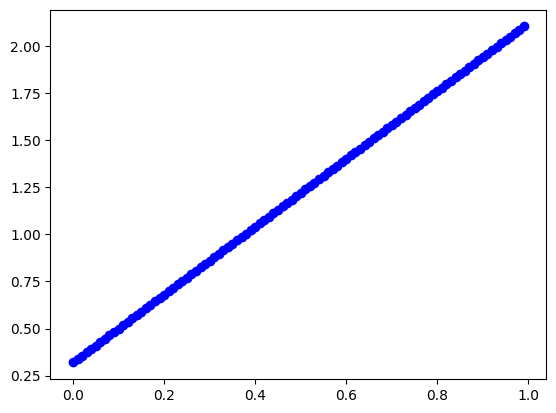

In [31]:
# 실제값
plt.scatter(x=scaled_data_C,
            y=scaled_data_F,
            c='b')
plt.show()

In [33]:
# 예측값
y_hat = model.predict([scaled_data_C])
for h, y in zip(y_hat, scaled_data_F):
        print('예측값:{}, 실제값:{}, 오차:{}'.format(h, y, h[0]-y))

4/4 [==============================] - 0s 2ms/step
예측값:[0.32169214], 실제값:0.32, 오차:0.0016921389102935724
예측값:[0.33963946], 실제값:0.33799999999999997, 오차:0.0016394550800323815
예측값:[0.3575868], 실제값:0.35600000000000004, 오차:0.0015868010520934672
예측값:[0.37553412], 실제값:0.374, 오차:0.0015341172218322763
예측값:[0.39348143], 실제값:0.392, 오차:0.0014814333915710298
예측값:[0.41142875], 실제값:0.41, 오차:0.0014287495613098389
예측값:[0.42937607], 실제값:0.428, 오차:0.0013760657310485924
예측값:[0.4473234], 실제값:0.446, 오차:0.0013234117031097337
예측값:[0.46527073], 실제값:0.46399999999999997, 오차:0.0012707278728485427
예측값:[0.48321807], 실제값:0.48200000000000004, 오차:0.0012180738449096284
예측값:[0.5011654], 실제값:0.5, 오차:0.0011653900146484375
예측값:[0.5191127], 실제값:0.518, 오차:0.001112706184387191
예측값:[0.53706], 실제값:0.536, 오차:0.0010600223541259446
예측값:[0.55500734], 실제값:0.554, 오차:0.0010073385238646981
예측값:[0.57295465], 실제값:0.5720000000000001, 오차:0.0009546546936034517
예측값:[0.59090203], 실제값:0.59, 오차:0.0009020304679870916
예측값:[0.6088493], 실제값:0.608, 오

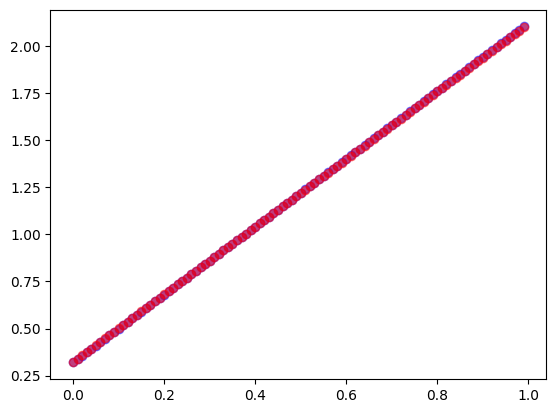

In [34]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', alpha=0.5) # 투명한 점그래프
plt.scatter(x=scaled_data_C, y=y_hat, c='r', alpha=0.5)

## 2.2 노이즈가 있는 데이터로 실습

In [37]:
np.random.seed(7)
noise = np.random.normal(0, scale=0.1, size=100) # 평균 0, 표준편차 0.1개 100개 데이터
noised_scaled_data_F = scaled_data_F + noise

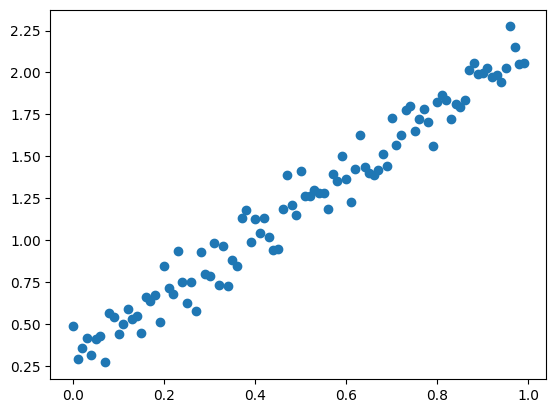

In [38]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [39]:
# 3. 모델구성
model2 = Sequential()
model2.add(Dense(1, input_shape=(1,)))
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
model2.summary() # 파라미터가 몇개인지 확인해야함

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [40]:
# 5. 모델 학습
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F, epochs=1000, verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.5572 - mae: 1.9134
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.5116 - mae: 1.9026
Epoch 3/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.4748 - mae: 1.8936
Epoch 4/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.4485 - mae: 1.8873
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.4213 - mae: 1.8807
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.3952 - mae: 1.8744
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.3702 - mae: 1.8682
Epoch 8/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.3457 - mae: 1.8622
Epoch 9/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.3236 - mae: 1.8568
Epoch 10/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.2988 - mae: 1.8508
Epoch 11/1000
4/4 [==============================] - 0s 2ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 2.6651 - mae: 1.3959
Epoch 89/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6463 - mae: 1.3901
Epoch 90/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6308 - mae: 1.3853
Epoch 91/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6115 - mae: 1.3794
Epoch 92/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5928 - mae: 1.3734
Epoch 93/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5751 - mae: 1.3679
Epoch 94/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5578 - mae: 1.3624
Epoch 95/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5407 - mae: 1.3571
Epoch 96/1000
4/4 [==============================] - 0s 1ms/step - loss: 2.5230 - mae: 1.3516
Epoch 97/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5053 - mae: 1.3459
Epoch 98/1000
4/4 [==============================] - 0s 1ms/step - loss: 2

4/4 [==============================] - 0s 2ms/step - loss: 1.3766 - mae: 0.9583
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3665 - mae: 0.9544
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3537 - mae: 0.9499
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3422 - mae: 0.9456
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3287 - mae: 0.9406
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3185 - mae: 0.9368
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.3071 - mae: 0.9325
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2961 - mae: 0.9285
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2839 - mae: 0.9240
Epoch 183/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2713 - mae: 0.9190
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.6148 - mae: 0.6500
Epoch 261/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6073 - mae: 0.6465
Epoch 262/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.6020 - mae: 0.6441
Epoch 263/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5958 - mae: 0.6411
Epoch 264/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5901 - mae: 0.6384
Epoch 265/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5838 - mae: 0.6354
Epoch 266/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5799 - mae: 0.6333
Epoch 267/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5747 - mae: 0.6310
Epoch 268/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5698 - mae: 0.6287
Epoch 269/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.5635 - mae: 0.6256
Epoch 270/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.3295 - mae: 0.4944
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3283 - mae: 0.4936
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3272 - mae: 0.4926
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3260 - mae: 0.4918
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3250 - mae: 0.4910
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3238 - mae: 0.4901
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3224 - mae: 0.4891
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3215 - mae: 0.4884
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3202 - mae: 0.4873
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3191 - mae: 0.4865
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

...

4/4 [==============================] - 0s 2ms/step - loss: 0.1148 - mae: 0.2875
Epoch 605/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1142 - mae: 0.2867
Epoch 606/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1137 - mae: 0.2861
Epoch 607/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1131 - mae: 0.2853
Epoch 608/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1125 - mae: 0.2845
Epoch 609/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1117 - mae: 0.2835
Epoch 610/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1112 - mae: 0.2828
Epoch 611/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1105 - mae: 0.2818
Epoch 612/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1099 - mae: 0.2810
Epoch 613/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1093 - mae: 0.2801
Epoch 614/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0707 - mae: 0.2230
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0703 - mae: 0.2223
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0699 - mae: 0.2217
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0693 - mae: 0.2207
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0689 - mae: 0.2200
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0685 - mae: 0.2193
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0681 - mae: 0.2187
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0676 - mae: 0.2180
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0671 - mae: 0.2171
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0667 - mae: 0.2163
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0389 - mae: 0.1643
Epoch 777/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0386 - mae: 0.1635
Epoch 778/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0383 - mae: 0.1629
Epoch 779/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0380 - mae: 0.1623
Epoch 780/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0377 - mae: 0.1616
Epoch 781/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0374 - mae: 0.1609
Epoch 782/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0371 - mae: 0.1603
Epoch 783/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0368 - mae: 0.1597
Epoch 784/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0365 - mae: 0.1590
Epoch 785/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0363 - mae: 0.1584
Epoch 786/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0197 - mae: 0.1148
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0195 - mae: 0.1144
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0193 - mae: 0.1140
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0192 - mae: 0.1134
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0189 - mae: 0.1128
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0188 - mae: 0.1122
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0187 - mae: 0.1117
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0185 - mae: 0.1112
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0184 - mae: 0.1106
Epoch 871/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0182 - mae: 0.1100
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0118 - mae: 0.0853
Epoch 949/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0117 - mae: 0.0851
Epoch 950/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0117 - mae: 0.0851
Epoch 951/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0117 - mae: 0.0849
Epoch 952/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0117 - mae: 0.0850
Epoch 953/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0116 - mae: 0.0847
Epoch 954/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0116 - mae: 0.0849
Epoch 955/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0116 - mae: 0.0849
Epoch 956/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0115 - mae: 0.0847
Epoch 957/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0115 - mae: 0.0846
Epoch 958/1000
4/4 [==============================] - 0s 2ms/step

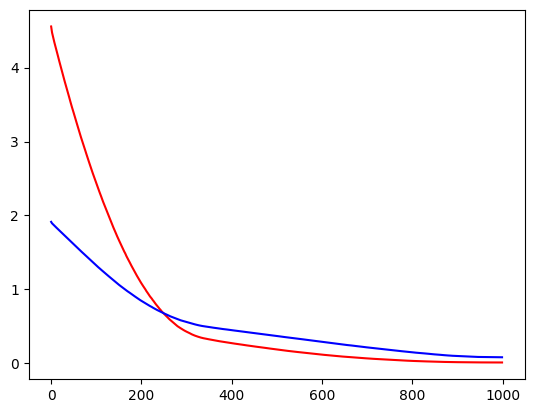

In [42]:
# 6. 학습된 모델 과정 살펴보기
plt.plot(hist2.history['loss'], c='r')
plt.plot(hist2.history['mae'], c='b')

In [48]:
model2.save('model/noise_after_learning.h5')

In [44]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 2ms/step


In [45]:
for h, y in zip(y_hat, noised_scaled_data_F):
    print("실제값:{}, 예측값:{}, 오차:{}".format(y, h, h[0]-y))

실제값:0.48905257038003563, 예측값:[0.33777654], 오차:-0.15127602867013573
실제값:0.2914062629459167, 예측값:[0.35550642], 오차:0.06410015718958134
실제값:0.3592820163678585, 예측값:[0.37323627], 오차:0.0139542523909153
실제값:0.4147516282996508, 예측값:[0.39096615], 오차:-0.02378548111527884
실제값:0.31310769713742614, 예측값:[0.40869603], 오차:0.09558832847254395
실제값:0.4102065572905948, 예측값:[0.42642587], 오차:0.016219316942651052
실제값:0.42791096141420687, 예측값:[0.44415575], 오차:0.016244791244637125
실제값:0.2705275693654579, 예측값:[0.46188563], 오차:0.19135806171898423
실제값:0.5657658005663493, 예측값:[0.4796155], 오차:-0.086150291056309
실제값:0.542049851591955, 예측값:[0.4973454], 오차:-0.04470446365631653
실제값:0.43745710260332404, 예측값:[0.5150752], 오차:0.07761810415326775
실제값:0.5008451738804279, 예측값:[0.5328051], 오차:0.03195991130176201
실제값:0.5865299374196752, 예측값:[0.55053496], 오차:-0.0359949738118871
실제값:0.5278643584808353, 예측값:[0.56826484], 오차:0.04040048355255088
실제값:0.5477250921327455, 예측값:[0.5859947], 오차:0.038269628326238925
실제값:0.44467585875092086

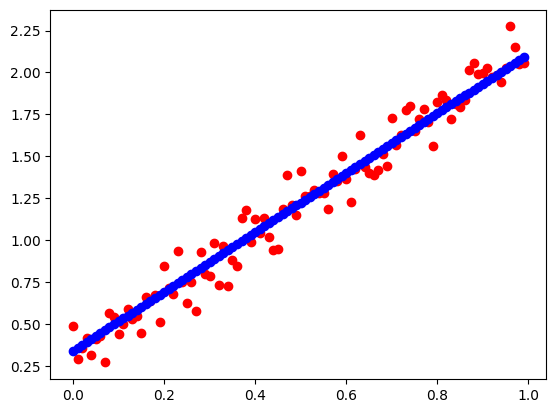

In [47]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='r')
plt.scatter(x=scaled_data_C, y=y_hat, c='b')